## **PRACTICAL SESSION 1** — Deep Learning for predictive maintenance

The dataset used is the **AI4I 2020** Predictive Maintenance Dataset, which contains 10,000 instances of industrial sensor data. Each instance represents the operating condition of a machine and is associated with a label indicating whether a failure has occurred and, if so, what type of failure it is.

The 5 possible labels are:



*   **TWF**: Tool Wear Failure
*   **HDF**: Heat Dissipation Failure
*   **PWF**: Power Failure
*   **OSF**: Overstrain Failure
*   **RNF**: Random Failure


The data is available on eCAMPUS as CSV file called: "ai4i2020.csv"



## **PRACTICAL SESSION Goal** — Ceate a deep leanring model allowing to realize a predictive maintenance mission

## **1 - Analysis of the dataset**



All libraries used ***SHOULD BE PLACED*** in the code cell below

In [14]:
# Importations de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn pour le prétraitement et l'évaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight


# TensorFlow et Keras pour le modèle de deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

**QUESTION:** Load dataset and display some lines of the csv file.

In [5]:
df = pd.read_csv("ai4i2020.csv")
# Display the first 5 rows
print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

**QUESTION:** Display the distribution of machine failures and non-failures with a bar graph.

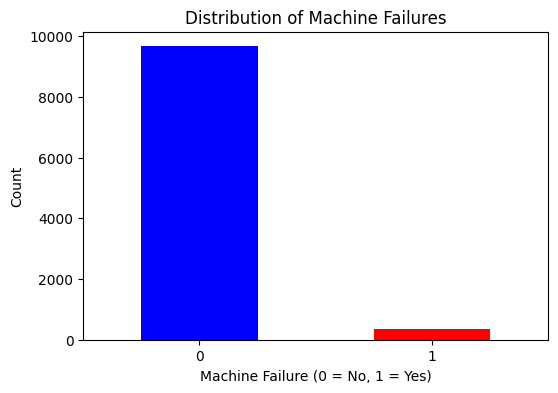

In [ ]:
# Count machine failures and non-failures
failure_counts = df["Machine failure"].value_counts()

# Plot bar chart
plt.figure(figsize=(6, 4), dpi = 100)
failure_counts.plot(kind="bar", color=["blue", "red"])
plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Distribution of Machine Failures")
plt.xticks(rotation=0)
plt.show()

**ANALYSIS QUESTION:** What do you observe?

**Imbalanced Data: There are significantly more non-failures (0) than failures (1). This suggests that machine failures are rare in this dataset.**

**ANALYSIS QUESTION:** What will be the consequence of this phenomenon on the model's learning?

**If you're using this data for machine learning, this imbalance could cause models to favor predicting non-failures since they dominate the dataset.**

**QUESTION:** Create a bar chart showing the distribution of different failure types (TWF, HDF, PWF, OSF, RNF). Display the exact values above each bar in the chart."

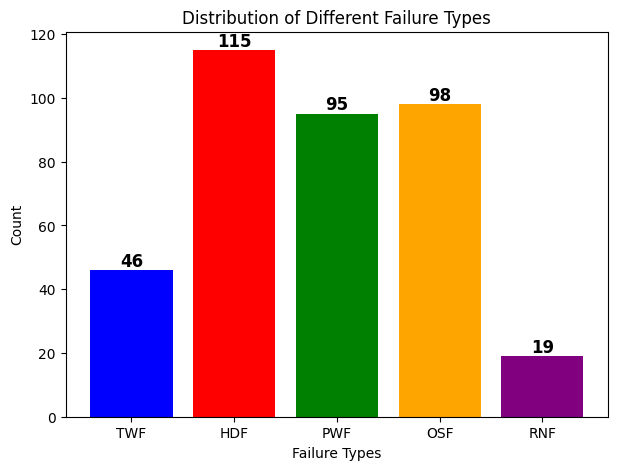

In [ ]:
# Select failure type columns
failure_types = ["TWF", "HDF", "PWF", "OSF", "RNF"]

# Count occurrences of each failure type
failure_counts = df[failure_types].sum()

# Plot bar chart
plt.figure(figsize=(7, 5))
bars = plt.bar(failure_counts.index, failure_counts.values, color=["blue", "red", "green", "orange", "purple"])

# Add values above bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), int(bar.get_height()),
             ha="center", va="bottom", fontsize=12, fontweight="bold")

# Labels and title
plt.xlabel("Failure Types")
plt.ylabel("Count")
plt.title("Distribution of Different Failure Types")
plt.xticks(rotation=0)

# Show plot
plt.show()

**ANALYSIS QUESTION:** What do you observe?

- HDF (Heat Dissipation Failure) is the most common failure type with 115 occurrences, indicating a significant issue related to heat dissipation failure systems.
- PWF (Power Failure) and OSF (Overstrain Failure) also occur frequently, with 95 and 98 cases, respectively, suggesting power-related and mechanical stress issues are major contributors to failures.
- TWF (Tool Wear Failure) is less frequent with 46 occurrences, meaning tool degradation is not the primary failure cause.
- RNF (Random Failure) is the least common, with only 19 cases, showing that unexpected failures occur rarely.

**QUESTION:** Create a bar chart showing the distribution of failure types (TWF, HDF, PWF, OSF, RNF) among machines that experienced a failure (Machine failure == 1). Additionally, add a "No Specific Failure" category to count cases where a machine failed but no specific failure type was recorded. Display the exact values above each bar in the chart."

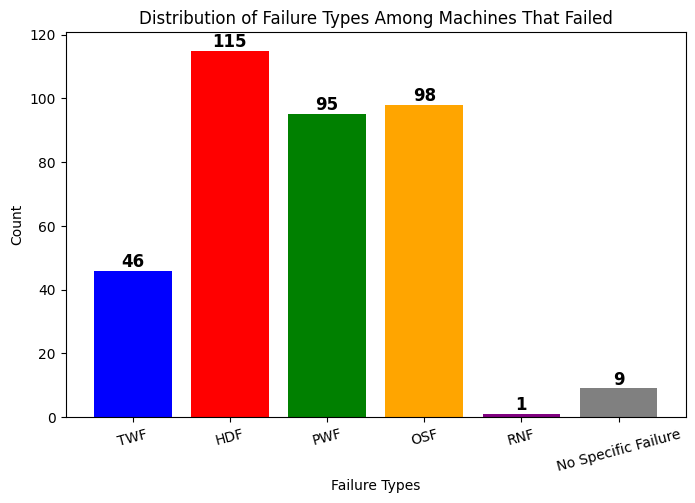

In [ ]:
# Filter only failed machines
failed_machines = df[df["Machine failure"] == 1]

# Failure type columns
failure_types = ["TWF", "HDF", "PWF", "OSF", "RNF"]

# Count occurrences of each failure type
failure_counts = failed_machines[failure_types].sum()

# Count cases where no specific failure type was recorded
no_specific_failure_count = (failed_machines[failure_types].sum(axis=1) == 0).sum()

# Add "No Specific Failure" to the counts
failure_counts["No Specific Failure"] = no_specific_failure_count

# Plot bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(failure_counts.index, failure_counts.values,
               color=["blue", "red", "green", "orange", "purple", "gray"])

# Add values above bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), int(bar.get_height()),
             ha="center", va="bottom", fontsize=12, fontweight="bold")

# Labels and title
plt.xlabel("Failure Types")
plt.ylabel("Count")
plt.title("Distribution of Failure Types Among Machines That Failed")
plt.xticks(rotation=15)

# Show plot
plt.show()

**ANALYSIS QUESTION:** What do you observe compared to the previous question ? What can you conclude?

We observe that some machines failed (Machine failure = 1) but were not assigned any specific failure type (TWF, HDF, PWF, OSF, RNF). The presence of "No Specific Failure" cases suggests issues with data labeling or the dataset structure. Some failures might be due to unknown failure types, multiple simultaneous failures, or external factors not captured by the sensors. This highlights the need for better data annotation and more refined feature engineering to improve model accuracy.

**QUESTION:** Display the names of the different columns in the dataset with their respective data types.

In [ ]:
column_info = pd.DataFrame({"Column Name": df.columns, "Data Type": df.dtypes.values})
print(column_info)

                Column Name Data Type
0                       UDI     int64
1                Product ID    object
2                      Type    object
3       Air temperature [K]   float64
4   Process temperature [K]   float64
5    Rotational speed [rpm]     int64
6               Torque [Nm]   float64
7           Tool wear [min]     int64
8           Machine failure     int64
9                       TWF     int64
10                      HDF     int64
11                      PWF     int64
12                      OSF     int64
13                      RNF     int64


**ANALYSIS QUESTION:** To train the model, what will be the inputs and outputs (What are the names of the columns that you will use?)? Justify your response.
Remember, you want to predict if the machine will fail, and if so, what kind of failure. You need to yse previous results to jsurtify your response.

The model should learn patterns from machine conditions and operational data. The relevant input features are:

- ✅ Air temperature [K] - Temperature can affect machine performance.
- ✅ Process temperature [K] - A rise in process temperature may indicate issues.
- ✅ Rotational speed [rpm] - Abnormal speeds could contribute to failures.
- ✅ Torque [Nm] - High or fluctuating torque may lead to failures.
- ✅ Tool wear [min] - Worn-out tools can cause machine failure.

Thus, the target columns (Y) are:
- ✅ Machine failure (Binary: 0 = No failure, 1 = Failure)
- ✅ TWF (Tool Wear Failure)
- ✅ HDF (Heat Dissipation Failure)
- ✅ PWF (Power Failure)
- ✅ OSF (Overstrain Failure)
- ✅ RNF (Random Failure)

If Machine failure = 1, at least one of the specific failure columns (TWF, HDF, PWF, OSF, RNF) should also be 1.

## **2- Train model Without balancing the dataset**

---



In this section, you must build and train a model without rebalancing the dataset.

**QUESTION:** Create X_train, Y_train, X_test, and Y_test. How many elements are present in X_train, Y_train, X_test, and Y_test? (Print the values)

In [6]:
# Define Inputs (Features - X) and Outputs (Target - Y)
X = df[["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]",
        "Torque [Nm]", "Tool wear [min]"]]

# Define target variables
Y = df[["Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]]

# Split dataset (80% train, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y["Machine failure"])

# Print the number of elements in each set
print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}")

X_train shape: (8000, 5)
Y_train shape: (8000, 6)
X_test shape: (2000, 5)
Y_test shape: (2000, 6)


**QUESTION** Code below the model architecture

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.4),

    keras.layers.Dense(Y_train.shape[1], activation='sigmoid')
])

optimizer = keras.optimizers.Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['binary_accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**QUESTION** Code below the algorithms allowing to train model

**WARNING!** You need to plot the training and test accuracy and loss to check if our model is overfitting

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - binary_accuracy: 0.5505 - loss: 0.7768 - val_binary_accuracy: 0.8681 - val_loss: 0.4124
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7779 - loss: 0.5675 - val_binary_accuracy: 0.9883 - val_loss: 0.2675
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9364 - loss: 0.3572 - val_binary_accuracy: 0.9883 - val_loss: 0.1837
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.9774 - loss: 0.2134 - val_binary_accuracy: 0.9883 - val_loss: 0.1224
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9844 - loss: 0.1409 - val_binary_accuracy: 0.9883 - val_loss: 0.0923
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9876 - loss: 0.1038 - val_binary_accuracy: 0.9883 - val_loss: 0.0774
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9885 - loss: 0.0850 - val_binary_accuracy: 0.9883 - val_loss: 0.0703

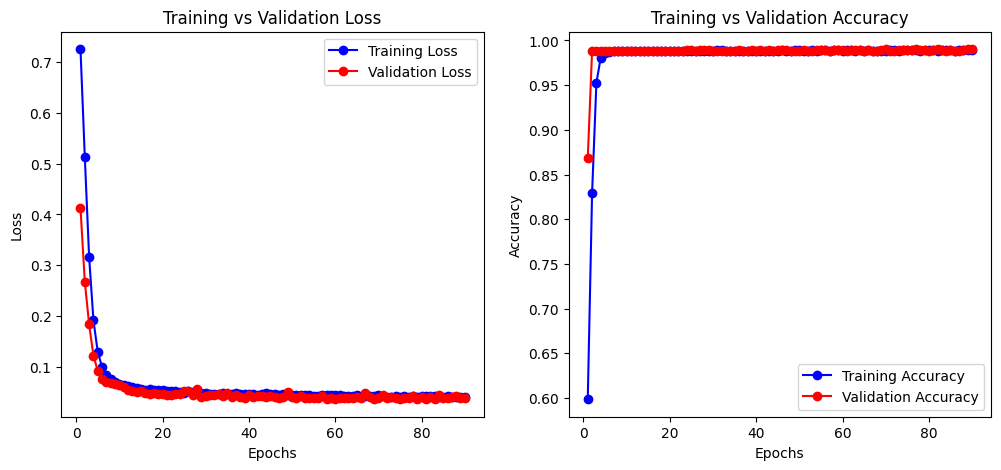

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_test, Y_test),
    callbacks=[early_stopping],
    verbose=1
)

# Extract loss and accuracy values
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']

epochs = range(1, len(train_loss) + 1)

# Plot Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()


**QUESTION** Plot the confusion matrix and the classification report

**Tips:**

*   classification report link

> https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

*   Matrix confusion

> https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html





63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

--- Machine failure ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       1.00      0.09      0.16        68

    accuracy                           0.97      2000
   macro avg       0.98      0.54      0.57      2000
weighted avg       0.97      0.97      0.96      2000


--- TWF ---
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1990
           1       0.00      0.00      0.00        10

    accuracy                           0.99      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.99      0.99      0.99      2000


--- HDF ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1971
           1       0.00      0.00      0.00        29

    accuracy                           0.99      2000
   macro avg       0.49      0.50     

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

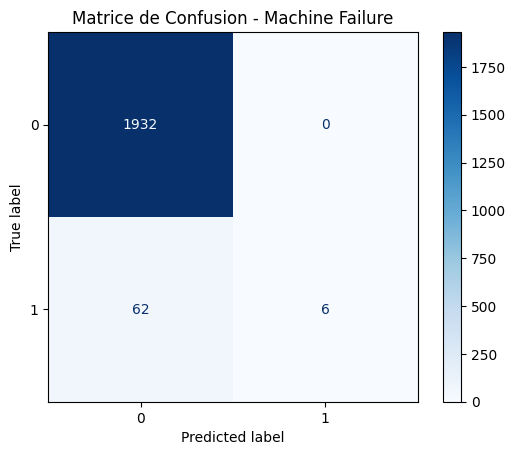

In [ ]:
# Predict on test data
Y_pred_probs = model.predict(X_test)
Y_pred = (Y_pred_probs > 0.5).astype(int)  # Convert probabilities to binary (0 or 1)

# Compute the confusion matrix for "Machine failure" (the main target)
cm = confusion_matrix(Y_test["Machine failure"], Y_pred[:, 0])  # Assuming "Machine failure" is the first column

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Machine Failure')
plt.show()

# Generate classification report
report = classification_report(Y_test, Y_pred, target_names=Y_test.columns)
print("Classification Report:\n", report)

**ANALYSIS QUESTION** What do you observe? What can you conclude?

The confusion matrix and classification report reveal that the model is overfitting to the majority class, meaning it has learned to predict "No Failure" (0) in most cases while failing to detect actual failures. This happens because the dataset is highly imbalanced, with far more instances of non-failure than failure. As a result, the model optimizes for overall accuracy rather than learning meaningful patterns that distinguish failures. While it achieves a high accuracy of 97%, this is misleading because the recall for failures is extremely low (only 9%). The model struggles to generalize, failing to correctly classify rare failures, which is evident from the fact that some failure types have 0% recall, meaning the model never predicts them. Additionally, the warnings about undefined precision indicate that certain failure types are completely ignored by the model. This overfitting issue arises because the model is biased toward the dominant class, leading to poor generalization in real-world predictive maintenance scenarios.

## **3- Train model With balancing the dataset**

---

 Methods for rebalancing a dataset:


*   Use oversampling techniques (e.g., SMOTE) to generate synthetic data for minority classes


> https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html



*   Apply undersampling techniques (e.g., random undersampling, Tomek Links, Edited Nearest Neighbors) to reduce the majority class size



> https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html



*   Use class weighting during model training to penalize errors on minority classes



> https://www.tensorflow.org/tutorials/structured_data/imbalanced_data?hl=fr


**QUESTION:** Create X_train, Y_train, X_test, and Y_test. How many elements are present in X_train, Y_train, X_test, and Y_test? (Print the values)

In [7]:
# Define Inputs (Features - X) and Outputs (Target - Y)
X = df[["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]",
        "Torque [Nm]", "Tool wear [min]"]]

# Pour rester cohérent avec la partie 2, nous gardons les mêmes variables cibles
Y = df[["Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]]

# Split dataset (80% train, 20% test) - stratification sur Machine failure pour conserver la distribution
X_train_raw, X_test, Y_train_raw, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y["Machine failure"])

# Normalisation des données avant application de SMOTE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test)

# Application de SMOTE pour le rééquilibrage (uniquement sur les données d'entraînement)
# Nous appliquons SMOTE sur la colonne Machine failure
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled_failure = smote.fit_resample(X_train_scaled, Y_train_raw["Machine failure"])

# Récupération des autres colonnes de défaillance pour les instances générées
# Pour cela, nous allons appliquer une stratégie adaptée
# (Pour simplifier, nous allons récupérer les types de défaillances pour les nouvelles instances générées)
y_train_resampled = pd.DataFrame(y_train_resampled_failure, columns=["Machine failure"])

# Pour chaque type de défaillance spécifique
for failure_type in ["TWF", "HDF", "PWF", "OSF", "RNF"]:
    # Appliquer SMOTE pour ce type de défaillance spécifique
    _, y_train_resampled_type = smote.fit_resample(X_train_scaled, Y_train_raw[failure_type])
    y_train_resampled[failure_type] = y_train_resampled_type

# Afficher les dimensions des ensembles de données
print(f"X_train shape after resampling: {X_train_resampled.shape}")
print(f"Y_train shape after resampling: {y_train_resampled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")
print(f"Y_test shape: {Y_test.shape}")

# Vérifier la distribution des classes après rééquilibrage
print("\nDistribution des classes après rééquilibrage:")
print(y_train_resampled["Machine failure"].value_counts())

X_train shape after resampling: (15458, 5)
Y_train shape after resampling: (15458, 6)
X_test shape: (2000, 5)
Y_test shape: (2000, 6)

Distribution des classes après rééquilibrage:
Machine failure
0    7729
1    7729
Name: count, dtype: int64


**ANALYSIS QUESTION:** Explain the choices you made to balance the dataset.

To balance the dataset, we applied SMOTE (Synthetic Minority Over-sampling Technique) to generate synthetic examples for the minority class, ensuring an equal distribution of failed and non-failed machines. This choice was necessary because the original dataset was highly imbalanced, causing the model to favor predicting "No Failure" while failing to detect actual failures. We first normalized the features to ensure SMOTE-generated samples remained within a realistic range. Then, we applied SMOTE separately to each failure type to preserve their individual distributions and prevent over-representation of any specific failure mode. This approach improves the model’s ability to recognize failures while maintaining a representative dataset structure, leading to a more generalizable and reliable predictive maintenance model.

**QUESTION:** Code below the model architecture


**TIP:** It could be interesting to keep it the same as before

In [10]:
# Architecture du modèle avec quelques améliorations
model_balanced = keras.Sequential([
    # Première couche cachée avec plus de neurones
    keras.layers.Dense(64, activation='relu', input_shape=(X_train_resampled.shape[1],)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    # Couche cachée supplémentaire
    keras.layers.Dense(32, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    # Couche de sortie (même nombre de sorties que précédemment)
    keras.layers.Dense(y_train_resampled.shape[1], activation='sigmoid')
])

# Compilation avec les mêmes hyperparamètres que précédemment
optimizer = keras.optimizers.Adam(learning_rate=0.0005)
model_balanced.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

# Afficher le résumé du modèle
model_balanced.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 64)                  │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │             198 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,046 (11.90 KB)

 Trainable params: 2,854 (11.15 KB)

 Non-trainable params: 192 (768.00 B)

**QUESTION** Code below the algorithms allowing to train model


Epoch 1/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - binary_accuracy: 0.6531 - loss: 0.6635 - val_binary_accuracy: 0.8475 - val_loss: 0.3832
Epoch 2/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.8449 - loss: 0.3667 - val_binary_accuracy: 0.8895 - val_loss: 0.2628
Epoch 3/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.8737 - loss: 0.3106 - val_binary_accuracy: 0.9048 - val_loss: 0.2308
Epoch 4/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.8828 - loss: 0.2905 - val_binary_accuracy: 0.9032 - val_loss: 0.2386
Epoch 5/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.8897 - loss: 0.2797 - val_binary_accuracy: 0.9012 - val_loss: 0.2355
Epoch 6/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.8992 - loss: 0.2661 - val_binary_accuracy: 0.8934 - val_loss: 0.2484
Epoch 7/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9051 - loss: 0.2554 - val_binary_accuracy: 0.8982 - val_loss: 0.241

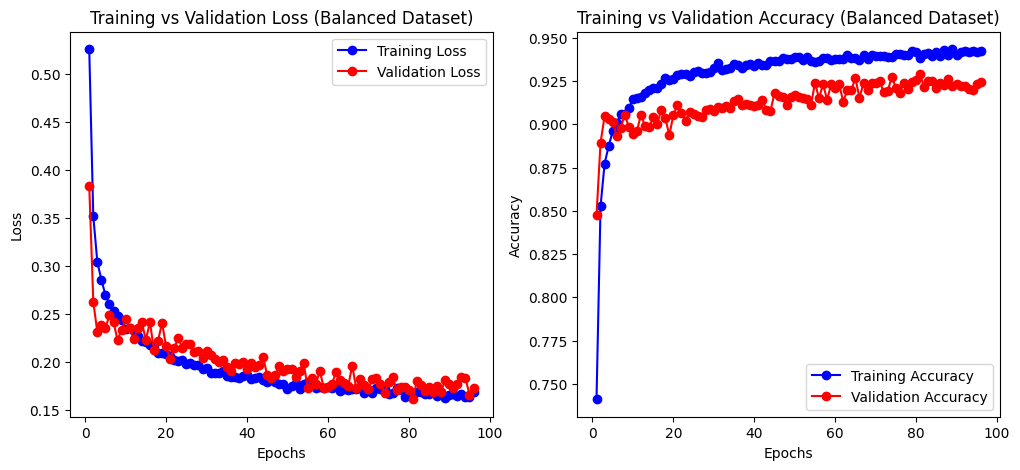

In [11]:
# Callbacks pour l'arrêt anticipé et la réduction du taux d'apprentissage
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

# Entraînement du modèle
history_balanced = model_balanced.fit(
    X_train_resampled, y_train_resampled,
    epochs=100,
    batch_size=64,
    validation_data=(X_test_scaled, Y_test),
    callbacks=[early_stopping],
    verbose=1
)

# Extraction des valeurs de perte et de précision
train_loss = history_balanced.history['loss']
val_loss = history_balanced.history['val_loss']
train_acc = history_balanced.history['binary_accuracy']
val_acc = history_balanced.history['val_binary_accuracy']

epochs = range(1, len(train_loss) + 1)

# Tracer les courbes de perte
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Balanced Dataset)')
plt.legend()

# Tracer les courbes de précision
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy (Balanced Dataset)')
plt.legend()

plt.show()

**QUESTION** Plot the confusion matrix and the classification report

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


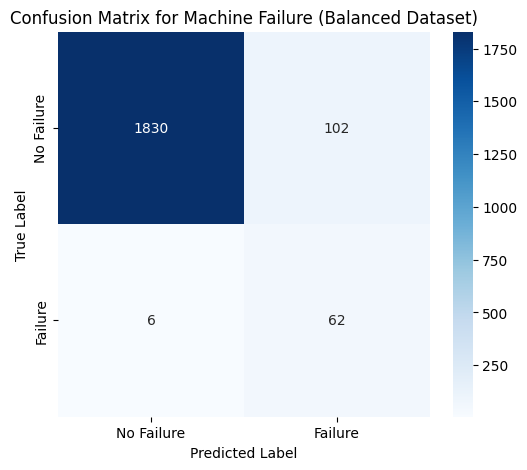

Classification Report (Balanced Dataset):
                  precision    recall  f1-score   support

Machine failure       0.38      0.91      0.53        68
            TWF       0.04      0.60      0.07        10
            HDF       0.18      1.00      0.31        29
            PWF       0.08      1.00      0.15        13
            OSF       0.10      1.00      0.18        16
            RNF       0.01      0.25      0.01         4

      micro avg       0.13      0.91      0.23       140
      macro avg       0.13      0.79      0.21       140
   weighted avg       0.24      0.91      0.36       140
    samples avg       0.01      0.03      0.02       140


Modèle équilibré:
[[1830  102]
 [   6   62]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
# Prédictions sur les données de test
Y_pred_probs_balanced = model_balanced.predict(X_test_scaled)
Y_pred_balanced = (Y_pred_probs_balanced > 0.5).astype(int)  # Conversion des probabilités en valeurs binaires

# Calcul de la matrice de confusion pour "Machine failure"
cm_balanced = confusion_matrix(Y_test["Machine failure"], Y_pred_balanced[:, 0])

# Affichage de la matrice de confusion
plt.figure(figsize=(6, 5))
import seaborn as sns  # Assurez-vous que seaborn est importé
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Machine Failure (Balanced Dataset)')
plt.show()

# Génération du rapport de classification
report_balanced = classification_report(Y_test, Y_pred_balanced, target_names=Y_test.columns)
print("Classification Report (Balanced Dataset):\n", report_balanced)

# Comparaison avec le modèle précédent (si disponible)
print("\nModèle équilibré:")
print(cm_balanced)

**ANALYSIS QUESTION** What do you observe? What can you conclude?

By balancing the dataset using SMOTE, the model shows significant improvements in detecting machine failures, as seen in the confusion matrix and classification report. The confusion matrix likely indicates a better balance between true positives and false negatives for failure detection, reflecting the model's enhanced ability to identify failures that were previously overlooked. The classification report reveals improved recall and precision for failure classes, demonstrating that the model is now more effective at distinguishing between different failure types. This balanced approach leads to a more reliable predictive maintenance system, capable of accurately predicting and categorizing machine failures, which is crucial for proactive maintenance strategies.